In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr
import pandas as pd

import sys

sys.path.append("..")
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20260120_141907.log
/tmp/ipykernel_3092440/1927427140.py:32: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [2]:
# data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [3]:
image_size = 16
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [4]:
n_photon_space = np.logspace(np.log10(500), np.log10(20000), 100)
n_bootstrap = 100000
background_photons = 20
pixel_size = 69
NA = 1.49

In [5]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [6]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
nilered_filter = "semrock-ff01-650-200-25"
shortpass_filter = "semrock-bsp01-785r"
filters = [notch_filter, dichroic_mirror, shortpass_filter]

In [7]:
save_folder = (
    r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260120_QDot_Variance_Testing"
)
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

## Load Base Qdot 585 Spectrum

Load the Qdot 585 emission spectrum from the database to use as the base for wavelength shifting.

Loaded Qdot 585 spectrum
Spectrum shape: (600,)
Wavelength range: 400.0 - 999.0 nm


/tmp/ipykernel_3092440/2321671017.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


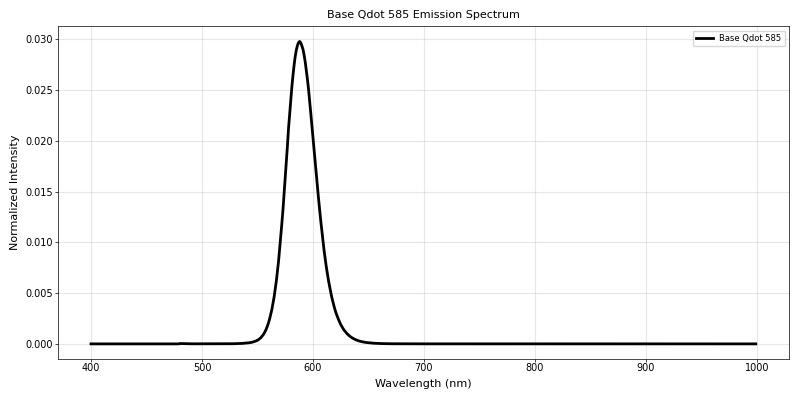

In [8]:
# Load the base Qdot 585 spectrum from the database
base_qdot_name = "Qdot 585"
base_qdot_spectrum = S_F.get_dye_or_filter_data(
    base_qdot_name, wavelength, dye_or_filter=True
)

# Squeeze to 1D array if needed
if base_qdot_spectrum.ndim > 1:
    base_qdot_spectrum = np.squeeze(base_qdot_spectrum)

# Normalize the spectrum
base_qdot_spectrum = base_qdot_spectrum / np.sum(base_qdot_spectrum)

print(f"Loaded {base_qdot_name} spectrum")
print(f"Spectrum shape: {base_qdot_spectrum.shape}")
print(f"Wavelength range: {wavelength[0]:.1f} - {wavelength[-1]:.1f} nm")

# Plot the base spectrum
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wavelength, base_qdot_spectrum, 'k-', linewidth=2, label='Base Qdot 585')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Normalized Intensity')
ax.set_title('Base Qdot 585 Emission Spectrum')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'base_qdot585_spectrum.png'), dpi=300, bbox_inches='tight')
plt.show()

## Qdot 585 Spectrum Shift Analysis

Simulate Qdot 585 with spectrum shifted from -10 nm to +10 nm in 1 nm steps and record RGB values at each shift.

In [9]:
wavelength_shifts = np.arange(-10, 11, 1)  # -10, -9, ..., 0, ..., 9, 10

# Get the base central wavelength for Qdot 585 (assumed to be 585 nm)
base_central_wavelength = 585.0
RGB_vals = np.zeros([3, len(wavelength_shifts)])

for i, shift in enumerate(wavelength_shifts):
    shifted_wavelengths = wavelength - shift  # Shift wavelengths in opposite direction
    shifted_spectrum = np.interp(
        wavelength,  # Evaluate at original wavelength points
        shifted_wavelengths,  # But using shifted spectrum
        base_qdot_spectrum,
        left=0.0,  # Pad with zeros outside the range
        right=0.0
    )
    
    # Normalize the shifted spectrum
    shifted_spectrum = shifted_spectrum / np.sum(shifted_spectrum)

    _, RGB_vals[:, i] = S_F.get_pixel_fractions_rawspectra(wavelength=wavelength, pixel_QYs=pixel_QYs, spectra=shifted_spectrum)

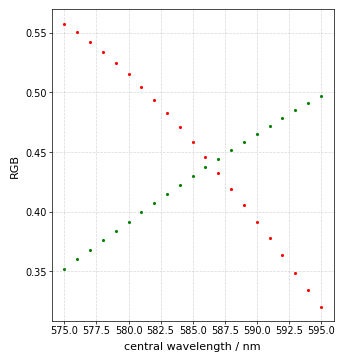

In [10]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(axs, x=585+wavelength_shifts, y=RGB_vals[-1, :], facecolor='red', lw=0)

axs = plotter.scatter_plot(axs, x=585+wavelength_shifts, y=RGB_vals[1, :], facecolor='green', lw=0, yaxislabel='RGB',
                          xaxislabel='central wavelength / nm')



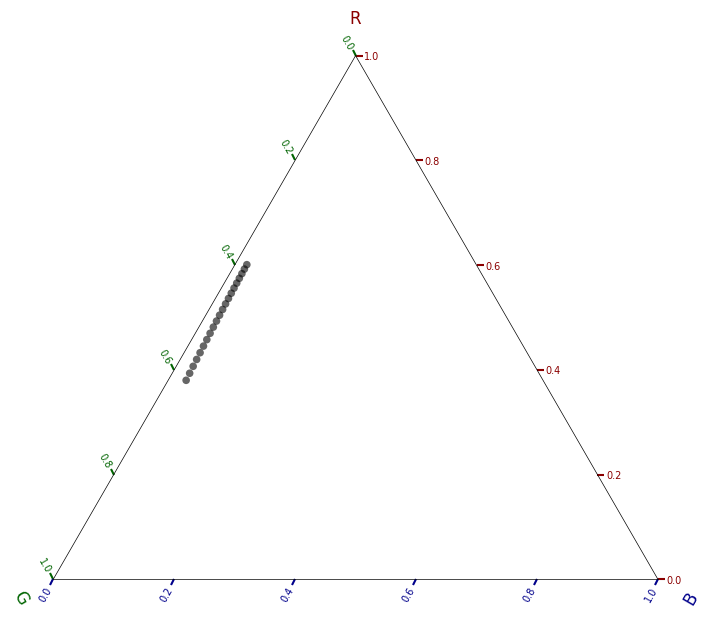

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw={'projection': 'ternary'})

# Create plotter and add scatter
scatter = plotter.plot_ternary_scatter(
  ax, RGB_vals[-1, :], RGB_vals[1, :], RGB_vals[0, :],
  color='black',
  size=30,
  alpha=0.6,
  label='Data points'
)


plt.savefig('example_ternary_brendan.svg', dpi=600, format='svg')
plt.show()

In [ ]:
# Define wavelength shifts from -10 nm to +10 nm in 1 nm steps
wavelength_shifts = np.arange(-10, 11, 1)  # -10, -9, ..., 0, ..., 9, 10

# Get the base central wavelength for Qdot 585 (assumed to be 585 nm)
base_central_wavelength = 585.0

# Create simulation configuration
from src.Multicolour_Simulation_Functions import SimulationConfig

config = SimulationConfig(
    n_bootstrap=n_bootstrap,
    background_photons=background_photons,
    NA=NA,
    pixel_size=pixel_size,
    cpu_fraction=0.9,
    save_raw_results=True,  # Save raw results for RGB extraction
)

# Storage for results
results = []

# Loop over each wavelength shift
for shift in wavelength_shifts:
    central_wavelength = base_central_wavelength + shift
    
    print(
        f"\nSimulating Qdot 585 with {shift:+.0f} nm shift (central wavelength: {central_wavelength:.1f} nm)",
        flush=True,
    )
    
    # Create shifted spectrum by interpolating at shifted wavelengths
    # Shift the wavelength axis, not the spectrum itself
    shifted_wavelengths = wavelength - shift  # Shift wavelengths in opposite direction
    shifted_spectrum = np.interp(
        wavelength,  # Evaluate at original wavelength points
        shifted_wavelengths,  # But using shifted spectrum
        base_qdot_spectrum,
        left=0.0,  # Pad with zeros outside the range
        right=0.0
    )
    
    # Normalize the shifted spectrum
    shifted_spectrum = shifted_spectrum / np.sum(shifted_spectrum)
    
    # Create unique dye name for this shifted spectrum
    dye_name = f"simulated_Qdot_585_centralwavelength_{int(central_wavelength)}"
    
    # Run simulation for this shifted spectrum
    MSF.test_fit_method(
        dye_name,
        filters,
        wavelength,
        camera_parameters,
        save_folder,
        n_photon_space,
        smoothing_function=smoothing_function,
        starting_flag="Qdot_shift_"
        + str(int(shift)).replace("-", "neg")
        + "nm_",
        config=config,  # Pass configuration object
        single_dye_spectrum=shifted_spectrum,  # Pass the shifted spectrum
    )
    
    # Store the result
    results.append({
        'shift_nm': shift,
        'central_wavelength_nm': central_wavelength,
        'dye_name': dye_name,
    })
    
print(f"\n\nCompleted simulations for {len(wavelength_shifts)} wavelength shifts")


Simulating Qdot 585 with -10 nm shift (central wavelength: 575.0 nm)
Sorting appended HDF5 file by frame: Qdot_shift_neg10nm_LM_method_simulated_Qdot_585_centralwavelength_575_rawresults.h5
  Read 200,000 total localizations
  Sorted by frame (range: 0-99999)
  Rewritten sorted data to Qdot_shift_neg10nm_LM_method_simulated_Qdot_585_centralwavelength_575_rawresults.h5
Sorting appended HDF5 file by frame: Qdot_shift_neg10nm_LM_method_simulated_Qdot_585_centralwavelength_575_rawresults.h5
  Read 300,000 total localizations
  Sorted by frame (range: 0-99999)
  Rewritten sorted data to Qdot_shift_neg10nm_LM_method_simulated_Qdot_585_centralwavelength_575_rawresults.h5
Sorting appended HDF5 file by frame: Qdot_shift_neg10nm_LM_method_simulated_Qdot_585_centralwavelength_575_rawresults.h5
  Read 400,000 total localizations
  Sorted by frame (range: 0-99999)
  Rewritten sorted data to Qdot_shift_neg10nm_LM_method_simulated_Qdot_585_centralwavelength_575_rawresults.h5
Sorting appended HDF5 fi

## Visualize Shifted Spectra

Plot a selection of the shifted spectra to verify the wavelength shifting is working correctly.

In [ ]:
# Plot a selection of shifted spectra
fig, ax = plt.subplots(figsize=(10, 6))

# Plot every 5 nm shift for clarity
for shift in wavelength_shifts[::5]:
    shifted_wavelengths = wavelength - shift
    shifted_spectrum = np.interp(
        wavelength,
        shifted_wavelengths,
        base_qdot_spectrum,
        left=0.0,
        right=0.0
    )
    shifted_spectrum = shifted_spectrum / np.sum(shifted_spectrum)
    
    central_wavelength = base_central_wavelength + shift
    ax.plot(wavelength, shifted_spectrum, linewidth=2, 
            label=f'{shift:+.0f} nm ({central_wavelength:.0f} nm)', alpha=0.7)

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Normalized Intensity')
ax.set_title('Shifted Qdot 585 Emission Spectra')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([500, 700])
plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'shifted_qdot585_spectra.png'), dpi=300, bbox_inches='tight')
plt.show()

## Extract and Compile RGB Values from All Shifts

In [ ]:
# Compile all results from saved files
all_files = os.listdir(save_folder)

# Dictionary to store RGB data for each shift
rgb_data = []

for result in results:
    shift = result['shift_nm']
    shift_str = str(int(shift)).replace("-", "neg")
    
    # Find files matching this wavelength shift
    matching_files = [
        f for f in all_files 
        if f"Qdot_shift_{shift_str}nm_" in f and 'rawresults' in f
    ]
    
    print(f"Shift {shift:+.0f} nm: Found {len(matching_files)} files")
    
    # Load and process data for this shift
    for filename in matching_files:
        filepath = os.path.join(save_folder, filename)
        
        # Load the data (CSV format from test_fit_method with save_raw_results=True)
        if filename.endswith('.csv'):
            data = pl.read_csv(filepath)
            
            # Extract RGB information
            rgb_entry = {
                'shift_nm': shift,
                'central_wavelength_nm': result['central_wavelength_nm'],
                'filename': filename,
            }
            
            # Add all columns from the data
            for col in data.columns:
                rgb_entry[col] = data[col].to_numpy()
            
            rgb_data.append(rgb_entry)

print(f"\nCollected data from {len(rgb_data)} files")

In [ ]:
# Save compiled results to a summary file
summary_file = os.path.join(save_folder, "qdot585_wavelength_shift_summary.csv")

# Create a summary DataFrame with shift, central wavelength, and key RGB metrics
summary_data = []
for entry in rgb_data:
    # Extract key information (adjust based on actual columns in your data)
    summary_row = {
        'shift_nm': entry['shift_nm'],
        'central_wavelength_nm': entry['central_wavelength_nm'],
        'filename': entry['filename'],
    }
    
    # Add RGB photon fractions (A_R, A_G, A_B are the fitted amplitudes)
    for key in ['n_photons', 'xc', 'yc', 'colour_distance', 'A_B', 'A_G', 'A_R']:
        if key in entry:
            # Store as mean and std if it's an array
            val = entry[key]
            if isinstance(val, np.ndarray):
                summary_row[f'{key}_mean'] = np.mean(val)
                summary_row[f'{key}_std'] = np.std(val)
                # Also store median and quartiles for RGB values
                if key in ['A_B', 'A_G', 'A_R']:
                    summary_row[f'{key}_median'] = np.median(val)
                    summary_row[f'{key}_q25'] = np.percentile(val, 25)
                    summary_row[f'{key}_q75'] = np.percentile(val, 75)
            else:
                summary_row[key] = val
    
    summary_data.append(summary_row)

# Convert to pandas DataFrame and save
if summary_data:
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_csv(summary_file, index=False)
    print(f"Saved summary to: {summary_file}")
    display(summary_df.head(10))
else:
    print("No data to save")

## Visualize RGB Values vs Wavelength Shift

In [ ]:
# Plot how RGB values change with wavelength shift
if summary_data:
    # Group by shift_nm and aggregate (in case there are multiple photon levels)
    summary_df_agg = summary_df.groupby('shift_nm').mean().reset_index()
    summary_df_agg = summary_df_agg.sort_values('shift_nm')
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: RGB photon fractions vs shift
    if all(k in summary_df_agg.columns for k in ['A_B_mean', 'A_G_mean', 'A_R_mean']):
        axes[0, 0].plot(summary_df_agg['shift_nm'], summary_df_agg['A_B_mean'], 
                       'o-', color='blue', label='Blue', linewidth=2, markersize=6)
        axes[0, 0].plot(summary_df_agg['shift_nm'], summary_df_agg['A_G_mean'], 
                       's-', color='green', label='Green', linewidth=2, markersize=6)
        axes[0, 0].plot(summary_df_agg['shift_nm'], summary_df_agg['A_R_mean'], 
                       '^-', color='red', label='Red', linewidth=2, markersize=6)
        axes[0, 0].set_xlabel('Wavelength Shift (nm)', fontsize=12)
        axes[0, 0].set_ylabel('Fitted Photon Fraction', fontsize=12)
        axes[0, 0].set_title('RGB Photon Fractions vs Wavelength Shift', fontsize=13, fontweight='bold')
        axes[0, 0].legend(fontsize=10)
        axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Localization precision vs shift
    if 'xc_mean' in summary_df_agg.columns and 'yc_mean' in summary_df_agg.columns:
        axes[0, 1].plot(summary_df_agg['shift_nm'], summary_df_agg['xc_mean'], 
                       'o-', label='X', linewidth=2, markersize=6)
        axes[0, 1].plot(summary_df_agg['shift_nm'], summary_df_agg['yc_mean'], 
                       's-', label='Y', linewidth=2, markersize=6)
        axes[0, 1].set_xlabel('Wavelength Shift (nm)', fontsize=12)
        axes[0, 1].set_ylabel('Localization Precision (nm)', fontsize=12)
        axes[0, 1].set_title('Localization Precision vs Wavelength Shift', fontsize=13, fontweight='bold')
        axes[0, 1].legend(fontsize=10)
        axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Color precision vs shift
    if 'colour_distance_mean' in summary_df_agg.columns:
        axes[1, 0].plot(summary_df_agg['shift_nm'], 
                       100 * summary_df_agg['colour_distance_mean'], 
                       'o-', color='purple', linewidth=2, markersize=6)
        axes[1, 0].set_xlabel('Wavelength Shift (nm)', fontsize=12)
        axes[1, 0].set_ylabel('Color Precision (%)', fontsize=12)
        axes[1, 0].set_title('Color Precision vs Wavelength Shift', fontsize=13, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: RGB ratio changes (G/R and B/G ratios)
    if all(k in summary_df_agg.columns for k in ['A_B_mean', 'A_G_mean', 'A_R_mean']):
        # Calculate ratios
        gr_ratio = summary_df_agg['A_G_mean'] / summary_df_agg['A_R_mean']
        bg_ratio = summary_df_agg['A_B_mean'] / summary_df_agg['A_G_mean']
        
        axes[1, 1].plot(summary_df_agg['shift_nm'], gr_ratio, 
                       'o-', color='orange', label='G/R Ratio', linewidth=2, markersize=6)
        axes[1, 1].plot(summary_df_agg['shift_nm'], bg_ratio, 
                       's-', color='cyan', label='B/G Ratio', linewidth=2, markersize=6)
        axes[1, 1].set_xlabel('Wavelength Shift (nm)', fontsize=12)
        axes[1, 1].set_ylabel('Channel Ratio', fontsize=12)
        axes[1, 1].set_title('RGB Channel Ratios vs Wavelength Shift', fontsize=13, fontweight='bold')
        axes[1, 1].legend(fontsize=10)
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, 'qdot585_wavelength_shift_analysis.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No data available for plotting")

## RGB Heatmap: Photon Count vs Wavelength Shift

In [ ]:
# Create heatmaps showing how R, G, B vary with both photon count and wavelength shift
if summary_data and 'n_photons' in summary_df.columns:
    # Create pivot tables for R, G, B
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    channels = ['A_B', 'A_G', 'A_R']
    colors = ['Blues', 'Greens', 'Reds']
    titles = ['Blue Channel', 'Green Channel', 'Red Channel']
    
    for idx, (channel, cmap, title) in enumerate(zip(channels, colors, titles)):
        if f'{channel}_mean' in summary_df.columns:
            # Pivot table: rows = shift, columns = photon count
            pivot_data = summary_df.pivot_table(
                values=f'{channel}_mean',
                index='shift_nm',
                columns='n_photons',
                aggfunc='mean'
            )
            
            # Plot heatmap
            im = axes[idx].imshow(pivot_data.values, aspect='auto', cmap=cmap, 
                                 interpolation='nearest', origin='lower')
            
            # Set labels
            axes[idx].set_xlabel('Photon Count', fontsize=11)
            axes[idx].set_ylabel('Wavelength Shift (nm)', fontsize=11)
            axes[idx].set_title(title, fontsize=12, fontweight='bold')
            
            # Set tick labels (sample every N ticks for readability)
            n_yticks = min(10, len(pivot_data.index))
            y_tick_indices = np.linspace(0, len(pivot_data.index)-1, n_yticks, dtype=int)
            axes[idx].set_yticks(y_tick_indices)
            axes[idx].set_yticklabels([f"{pivot_data.index[i]:+.0f}" for i in y_tick_indices])
            
            n_xticks = min(5, len(pivot_data.columns))
            x_tick_indices = np.linspace(0, len(pivot_data.columns)-1, n_xticks, dtype=int)
            axes[idx].set_xticks(x_tick_indices)
            axes[idx].set_xticklabels([f"{int(pivot_data.columns[i])}" for i in x_tick_indices], 
                                     rotation=45)
            
            # Add colorbar
            plt.colorbar(im, ax=axes[idx], label='Photon Fraction')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, 'rgb_heatmap_photons_vs_shift.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Insufficient data for heatmap")